# Dimensionality analysis of layered materials

This notebook follows the [official ASE dimensionality-analysis tutorial](https://ase.gitlab.io/ase/examples_generated/03-tutorials/dimensionality.html). It classifies the connected components of periodic MoS₂ models, labels the components in a layered structure, isolates two distinct monolayers, and adds a small sensitivity test for the out-of-plane cell height and analysis method.

### Learning goals

- distinguish geometric periodicity from the dimensionality of bonded components;
- interpret ASE's $k$ intervals, component histogram, dimensionality score, and atom labels;
- extract disconnected 0D, 1D, 2D, or 3D components as separate `Atoms` objects; and
- recognize that the classification depends on geometry, periodic boundaries, covalent radii, and the selected connectivity interval.

Distances and cell dimensions are in ångström (Å). The $k$ values and dimensionality scores are dimensionless. No energy calculator is used: this is a geometric and topological analysis, not a calculation of bonding strength or exfoliation energy.

## Connectivity and $k$-interval analysis

ASE introduces candidate bonds in order of the scaled separation

$$
k_{ij} = \frac{d_{ij}}{r_i^{cov} + r_j^{cov}},
$$

where $d_{ij}$ is the interatomic distance and $r_i^{cov}$ and $r_j^{cov}$ are tabulated covalent radii. As $k$ increases, more atom pairs become connected. The intervals between connectivity changes are the $k$ intervals returned by `analyze_dimensionality()`.

Within each interval, ASE determines whether every connected component is finite (0D), extends along one lattice direction (1D), spans a plane (2D), or forms a three-dimensional periodic network (3D). A mixed label such as `02D` means that 0D and 2D components coexist at that connectivity. The score measures how strongly an interval contributes under ASE's interval-scoring function; it is not a statistical probability, although the merged interval scores are normalized to sum to one.

## Classifying a periodic MoS₂ stack

`mx2()` constructs a 2H-MoS₂ monolayer with in-plane lattice constant `a=3.18 Å` and S–S layer thickness `3.19 Å`. The code supplies a 7 Å out-of-plane cell vector, enables periodicity in all three directions, and repeats the three-atom unit along every cell vector. The resulting $3 \times 3 \times 3$ model contains 81 atoms arranged as three disconnected MoS₂ layers in the repeated cell.

Full three-dimensional periodic boundary conditions do **not** force the bonded component to be 3D. They only permit bonds to cross all three cell boundaries; the connectivity analysis still finds whether such bonds actually occur. Here, the large interlayer gap prevents bonds along $z$, so each component spans only the in-plane lattice directions.

`method='RDA'` selects the rank-determination algorithm. The returned intervals are sorted by decreasing score, making `intervals[0]` the preferred classification. The stored output

```text
2D (0, 0, 3, 0) 0.96718 0.93901 1.81429
```

means that the best interval contains three 2D components and no 0D, 1D, or 3D components. Its score is approximately 0.967, and the interval extends from $k=0.939$ to $k=1.814$. The tuple `h=(0, 0, 3, 0)` is ordered as the counts of 0D, 1D, 2D, and 3D components.

`m.components` assigns a component identifier to every atom. Storing those identifiers as tags makes later selection or component-aware coloring possible. The static plot itself remains a geometric projection; tags do not change the atomic structure.

1.0
2D (0, 0, 3, 0) 0.9671801741460148 0.9390120940780232 1.8142857142857145


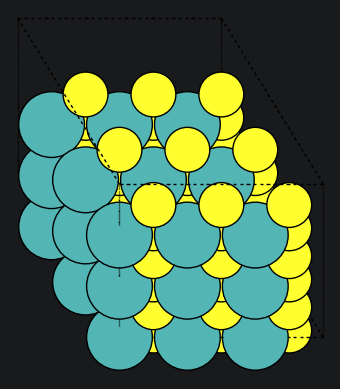

In [1]:
import ase.build
from ase.geometry.dimensionality import analyze_dimensionality

atoms = ase.build.mx2(formula='MoS2', kind='2H', a=3.18, thickness=3.19)
atoms.cell[2, 2] = 7.0
atoms.set_pbc((1, 1, 1))
atoms *= 3

intervals = analyze_dimensionality(atoms, method='RDA')
m = intervals[0]
print(sum([e.score for e in intervals]))
print(m.dimtype, m.h, m.score, m.a, m.b)

atoms.set_tags(m.components)

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

fig, ax = plt.subplots()
plot_atoms(atoms, ax, rotation=('-20x,0y, 0z'))
ax.set_axis_off()

## Isolating components from a mixed stack

The second example builds separate $4 \times 4$ sheets of 2H- and 1T-MoS₂. Each sheet contains 48 atoms. Their atomic numbers and positions are concatenated into one 96-atom periodic structure, with the 1T sheet translated upward by 7 Å inside a 14 Å out-of-plane cell.

`isolate_components()` first selects a connectivity cutoff from the dimensionality analysis, then returns a dictionary grouped by component dimensionality. Both polytypes are extended only in two directions, so the result is `{'2D': [component_1, component_2]}` and the printed count is two 2D components. Dimensionality analysis separates the sheets, but it does not assign the crystallographic labels 2H and 1T; that distinction must be retained from construction or determined by a separate structural analysis.

ASE standardizes an isolated 2D component into the $xy$ plane with periodic boundaries `(True, True, False)`. Its out-of-plane cell length has no physical meaning until suitable vacuum is added. Similarly, isolated 0D and 1D objects receive canonical nonperiodic or chain-aligned cells, whereas a 3D component retains the original cell.

In [2]:
import numpy as np

import ase.build
from ase import Atoms
from ase.geometry.dimensionality import isolate_components

# build two slabs of different types of MoS2
rep = [4, 4, 1]
a = ase.build.mx2(formula='MoS2', kind='2H', a=3.18, thickness=3.19) * rep
b = ase.build.mx2(formula='MoS2', kind='1T', a=3.18, thickness=3.19) * rep
positions = np.concatenate([a.get_positions(), b.get_positions() + [0, 0, 7]])
numbers = np.concatenate([a.numbers, b.numbers])
cell = a.cell
atoms = Atoms(numbers=numbers, positions=positions, cell=cell, pbc=[1, 1, 1])
atoms.cell[2, 2] = 14.0

# isolate each component in the whole material
result = isolate_components(atoms)
print('counts:', [(k, len(v)) for k, v in sorted(result.items())])

for dim, components in result.items():
    for atoms in components:
        print(dim)

counts: [('2D', 2)]
2D
2D


## Extension: sensitivity to layer spacing and method

A dimensionality label is meaningful only for the geometry actually supplied. Reducing the out-of-plane cell height moves periodic images closer together; once the scaled interlayer separations enter the dominant $k$ interval, the layers can become one connected 3D network. The following inexpensive probe rebuilds the same repeated MoS₂ model at several cell heights and compares RDA with ASE's topology-scaling algorithm (TSA).

Because the physical sheet thickness remains 3.19 Å, changing the cell height also changes the empty interlayer gap. This is a sensitivity test for the connectivity model, not a simulated compression or structural relaxation.

In [3]:
cell_heights = [4.5, 6.0, 7.0, 9.0, 12.0]  # Å

print('cell height (Å) | RDA type/score | TSA type/score')
print('-' * 52)

for cell_height in cell_heights:
    probe = ase.build.mx2(
        formula='MoS2', kind='2H', a=3.18, thickness=3.19
    )
    probe.cell[2, 2] = cell_height
    probe.set_pbc((1, 1, 1))
    probe *= 3

    best = {
        method: analyze_dimensionality(probe, method=method)[0]
        for method in ('RDA', 'TSA')
    }
    print(
        f'{cell_height:15.1f} | '
        f'{best["RDA"].dimtype:>3}/{best["RDA"].score:.3f}      | '
        f'{best["TSA"].dimtype:>3}/{best["TSA"].score:.3f}'
    )

cell height (Å) | RDA type/score | TSA type/score
----------------------------------------------------
            4.5 |  3D/1.000      |  3D/1.000
            6.0 |  2D/0.836      |  2D/0.836
            7.0 |  2D/0.967      |  2D/0.967
            9.0 |  2D/0.993      |  2D/0.993
           12.0 |  2D/0.997      |  2D/0.997


## Reference suite: 0D, 1D, 2D, and 3D

A controlled set of idealized structures makes the dimensionality labels concrete:

| Reference structure | Periodic directions | Expected result |
|---|---|---|
| isolated H₂O molecule | none | 0D |
| one-atom carbon chain | $z$ | 1D |
| graphene monolayer | $x$, $y$ | 2D |
| diamond Si crystal | $x$, $y$, $z$ | 3D |

The carbon chain uses a chosen 1.42 Å repeat distance and 8 Å nonperiodic cell lengths in $x$ and $y$. It is a connectivity reference rather than an optimized physical model. Graphene receives 5 Å of vacuum on each side, although its nonperiodic $z$ direction already limits the maximum component dimensionality to 2D.

Each assertion compares the highest-scoring RDA interval with the expected label. If a future geometry or ASE change alters one of these basic classifications, the cell fails immediately instead of allowing the change to pass unnoticed.

In [4]:
from ase import Atoms
from ase.build import bulk, graphene, molecule
from ase.geometry.dimensionality import analyze_dimensionality

carbon_chain = Atoms(
    'C',
    positions=[(0.0, 0.0, 0.0)],
    cell=(8.0, 8.0, 1.42),  # Å
    pbc=(False, False, True),
)

reference_systems = [
    ('H2O molecule', molecule('H2O'), '0D'),
    ('periodic C chain', carbon_chain, '1D'),
    ('graphene layer', graphene(a=2.46, vacuum=5.0), '2D'),
    ('diamond Si', bulk('Si', 'diamond', a=5.43), '3D'),
]

print('structure          | PBC | expected | detected | score')
print('-' * 58)

reference_results = {}
for name, structure, expected in reference_systems:
    best_interval = analyze_dimensionality(structure, method='RDA')[0]
    detected = best_interval.dimtype
    pbc_label = ''.join('1' if value else '0' for value in structure.pbc)
    reference_results[name] = best_interval

    print(
        f'{name:<18} | {pbc_label} | {expected:^8} | '
        f'{detected:^8} | {best_interval.score:.3f}'
    )
    assert detected == expected, (
        f'{name}: expected {expected}, detected {detected}'
    )

structure          | PBC | expected | detected | score
----------------------------------------------------------
H2O molecule       | 000 |    0D    |    0D    | 1.000
periodic C chain   | 001 |    1D    |    1D    | 1.000
graphene layer     | 110 |    2D    |    2D    | 1.000
diamond Si         | 111 |    3D    |    3D    | 0.866


### Interpreting the sensitivity test

With ASE 3.29, both algorithms classify the 4.5 Å model as 3D because the periodic layers are close enough to become connected by the covalent-radius criterion. At 6 Å and above, both return 2D; the preferred 2D score increases as the layers are separated further. Agreement between RDA and TSA is reassuring for this simple example, but it does not remove the dependence on the supplied structure and radius-based connectivity model.

### Interpreting the reference suite

All four assertions pass with ASE 3.29. The molecule, chain, and monolayer receive scores of 1.000, while diamond Si is correctly identified as 3D with a preferred score of approximately 0.866. A score below one does not invalidate the label; it indicates that other connectivity intervals retain some weight under the scoring function.

The examples also show that periodic-boundary flags set the directions in which a component *can* extend, while interatomic connectivity determines whether it actually does. These ideal structures are useful controls, not evidence about energetic stability.

## Takeaways and possible extensions

Dimensionality analysis asks how connected components extend through periodic images. It can distinguish low-dimensional components inside a fully periodic cell and can extract those components into standardized `Atoms` objects. The result is topological: it does not evaluate bond energy, electronic coupling, mechanical stability, or whether a layer is experimentally exfoliable.

The reference suite now provides a compact regression check for the four basic dimensionalities. Further extensions could include:

1. printing each isolated component's formula, atom count, cell, and periodic-boundary flags;
2. plotting the two isolated MoS₂ polytypes side by side with explicit component colors;
3. displaying every $k$ interval rather than only the highest-scoring result;
4. testing mixed-dimensional structures such as molecular guests between layers or chains inside a 3D host;
5. comparing the inferred components with chemically motivated neighbor cutoffs; and
6. exporting isolated structures only after adding physically meaningful vacuum to nonperiodic directions.

For real materials screening, inspect borderline scores and the atomic geometry rather than treating the top label as an infallible chemical classification.